# Ronit Part: Figure Reproductions for Photonic Boson Sampling

This notebook contains the figure-reproduction portion of our PH530 project based on the paper **"Photonic Boson Sampling in a Tunable Circuit"** by Broome *et al.* The notebook is designed so that it can be presented directly during the video.

The focus here is on the plots corresponding to:

- Fig. 2: two-photon Boson Sampling,
- Fig. 3: three-photon Boson Sampling,
- Fig. 4(b): three-photon Boson Sampling with colliding outputs,
- Fig. 5: source-imperfection trend with pump power.

Each reproduced graph is preceded by a markdown explanation describing:

- what part of the paper it corresponds to,
- what is being computed,
- how the graph is generated in the notebook,
- and what should be said while presenting it.

## Scope of reproduction

In this notebook, the **theory-based quantities** are computed directly from the measured unitary matrices published in the supplementary material. These include:

- permanent-based bosonic probabilities,
- distinguishable-particle comparison probabilities,
- visibilities derived from those probabilities,
- coherent-state visibility predictions derived from the supplementary formulas.

For the experimental comparison:

- the summary $L_1$ values quoted in the paper are included exactly as reported in the text,
- the Fig. 5 trend is recreated from the plotted figure and therefore should be treated as an approximate graphical transcription,
- Bob's individual measured bars in Figs. 2 to 4 are not numerically tabulated in the PDF, so the notebook reproduces the theoretical structure of those figures rather than claiming exact recovery of the raw experimental bars.

In [1]:
import cmath
import itertools
import math
import random


def permanent(matrix):
    n = len(matrix)
    if n == 0:
        return 1
    total = 0j
    for perm in itertools.permutations(range(n)):
        term = 1 + 0j
        for i in range(n):
            term *= matrix[i][perm[i]]
        total += term
    return total


def build_submatrix(U, input_occ, output_occ):
    cols = []
    for j, count in enumerate(output_occ):
        cols.extend([j] * count)

    rows = []
    for i, count in enumerate(input_occ):
        rows.extend([i] * count)

    return [[U[i][j] for j in cols] for i in rows]


def factorial_product(occ):
    out = 1
    for x in occ:
        out *= math.factorial(x)
    return out


def quantum_probability(U, input_occ, output_occ):
    sub = build_submatrix(U, input_occ, output_occ)
    amp = permanent(sub)
    norm = math.sqrt(factorial_product(input_occ) * factorial_product(output_occ))
    return (abs(amp) ** 2) / (norm ** 2), sub


def classical_probability(U, input_occ, output_occ):
    sub = build_submatrix(U, input_occ, output_occ)
    weight = [[abs(z) ** 2 for z in row] for row in sub]
    return permanent(weight).real


def visibility(Pc, Pq):
    if abs(Pc) < 1e-15:
        return float("nan")
    return ((Pc - Pq) / Pc).real


def occ_from_modes(modes, m=6):
    occ = [0] * m
    for mode in modes:
        occ[mode - 1] += 1
    return tuple(occ)


def choose_noncolliding_outputs(n, m=6):
    for combo in itertools.combinations(range(1, m + 1), n):
        yield combo, occ_from_modes(combo, m=m)


def coherent_visibility(U, input_modes, output_modes, samples=4000, seed=7):
    rng = random.Random(seed)
    input_idx = [m - 1 for m in input_modes]
    output_idx = [m - 1 for m in output_modes]

    p0 = 0.0
    for _ in range(samples):
        phases = [rng.uniform(0.0, 2.0 * math.pi) for _ in input_idx]
        prod = 1.0
        for out_j in output_idx:
            amp = 0j
            for idx, in_i in enumerate(input_idx):
                amp += U[in_i][out_j] * cmath.exp(1j * phases[idx])
            prod *= abs(amp) ** 2
        p0 += prod
    p0 /= samples

    p_inf = 1.0
    for out_j in output_idx:
        incoherent_intensity = sum(abs(U[in_i][out_j]) ** 2 for in_i in input_idx)
        p_inf *= incoherent_intensity

    return visibility(p_inf, p0)


def display_table(rows, headers):
    widths = [len(h) for h in headers]
    for row in rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(str(cell)))

    def fmt(row):
        return " | ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(row))

    print(fmt(headers))
    print("-+-".join("-" * w for w in widths))
    for row in rows:
        print(fmt(row))


def show_svg(svg):
    try:
        from IPython.display import SVG, display
        display(SVG(svg))
    except Exception:
        print(svg)


def svg_visibility_panel(title, labels, quantum_vals, coherent_vals, y_min=-1.1, y_max=1.1):
    width = 980
    height = 360
    margin_left = 70
    margin_right = 20
    margin_top = 45
    margin_bottom = 115
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom

    def y_map(v):
        return margin_top + (y_max - v) * plot_h / (y_max - y_min)

    zero_y = y_map(0.0)
    n = len(labels)
    slot = plot_w / max(n, 1)
    bar_w = slot * 0.60

    pieces = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        f'<text x="{width/2}" y="26" font-size="22" text-anchor="middle" font-family="Arial">{title}</text>',
        f'<line x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{margin_top + plot_h}" stroke="black"/>',
        f'<line x1="{margin_left}" y1="{zero_y}" x2="{margin_left + plot_w}" y2="{zero_y}" stroke="black"/>',
    ]

    for tick in [-1.0, -0.5, 0.0, 0.5, 1.0]:
        y = y_map(tick)
        pieces.append(f'<line x1="{margin_left}" y1="{y}" x2="{margin_left + plot_w}" y2="{y}" stroke="#dddddd"/>')
        pieces.append(f'<text x="{margin_left-10}" y="{y+4}" font-size="11" text-anchor="end" font-family="Arial">{tick:.1f}</text>')

    for i, label in enumerate(labels):
        x_center = margin_left + slot * (i + 0.5)
        x = x_center - bar_w / 2
        y_q = y_map(quantum_vals[i])
        top = min(y_q, zero_y)
        height_rect = abs(zero_y - y_q)
        pieces.append(f'<rect x="{x}" y="{top}" width="{bar_w}" height="{height_rect}" fill="#f8b4b4" stroke="#5a67d8" stroke-width="1.2"/>')

        y_c = y_map(coherent_vals[i])
        pieces.append(f'<circle cx="{x_center}" cy="{y_c}" r="4" fill="#f6e05e" stroke="#444444" stroke-width="1"/>')

        pieces.append(
            f'<text x="{x_center}" y="{margin_top + plot_h + 14}" font-size="10" text-anchor="end" transform="rotate(-45 {x_center},{margin_top + plot_h + 14})" font-family="Arial">{label}</text>'
        )

    pieces.append(f'<rect x="{width-240}" y="18" width="16" height="10" fill="#f8b4b4" stroke="#5a67d8" stroke-width="1.2"/>')
    pieces.append(f'<text x="{width-218}" y="28" font-size="12" font-family="Arial">Quantum visibility</text>')
    pieces.append(f'<circle cx="{width-112}" cy="24" r="4" fill="#f6e05e" stroke="#444444" stroke-width="1"/>')
    pieces.append(f'<text x="{width-98}" y="28" font-size="12" font-family="Arial">Coherent-state prediction</text>')
    pieces.append("</svg>")
    return "".join(pieces)


def svg_line_chart(title, x_vals, series, x_label, y_label, y_min=None, y_max=None):
    width = 860
    height = 470
    margin_left = 80
    margin_right = 20
    margin_top = 50
    margin_bottom = 70
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom

    all_y = []
    for item in series:
        all_y.extend(item["y"])
    if y_min is None:
        y_min = min(all_y)
    if y_max is None:
        y_max = max(all_y)
    x_min = min(x_vals)
    x_max = max(x_vals)

    def x_map(x):
        return margin_left + (x - x_min) * plot_w / (x_max - x_min)

    def y_map(y):
        return margin_top + (y_max - y) * plot_h / (y_max - y_min)

    pieces = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        f'<text x="{width/2}" y="28" font-size="22" text-anchor="middle" font-family="Arial">{title}</text>',
        f'<line x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{margin_top + plot_h}" stroke="black"/>',
        f'<line x1="{margin_left}" y1="{margin_top + plot_h}" x2="{margin_left + plot_w}" y2="{margin_top + plot_h}" stroke="black"/>',
    ]

    for tick in range(6):
        frac = tick / 5
        y_val = y_min + frac * (y_max - y_min)
        y = y_map(y_val)
        pieces.append(f'<line x1="{margin_left}" y1="{y}" x2="{margin_left + plot_w}" y2="{y}" stroke="#dddddd"/>')
        pieces.append(f'<text x="{margin_left-10}" y="{y+4}" font-size="11" text-anchor="end" font-family="Arial">{y_val:.3f}</text>')

    for x in x_vals:
        x_pos = x_map(x)
        pieces.append(f'<line x1="{x_pos}" y1="{margin_top + plot_h}" x2="{x_pos}" y2="{margin_top + plot_h + 5}" stroke="black"/>')
        pieces.append(f'<text x="{x_pos}" y="{margin_top + plot_h + 20}" font-size="11" text-anchor="middle" font-family="Arial">{x}</text>')

    for item in series:
        pts = " ".join(f"{x_map(x)},{y_map(y)}" for x, y in zip(x_vals, item["y"]))
        pieces.append(f'<polyline fill="none" stroke="{item["color"]}" stroke-width="2.2" stroke-dasharray="{item.get("dash", "none")}" points="{pts}"/>')
        for x, y in zip(x_vals, item["y"]):
            pieces.append(f'<circle cx="{x_map(x)}" cy="{y_map(y)}" r="4" fill="{item["color"]}" stroke="white" stroke-width="1"/>')

    legend_x = width - 235
    legend_y = 65
    for idx, item in enumerate(series):
        yy = legend_y + idx * 20
        pieces.append(f'<line x1="{legend_x}" y1="{yy}" x2="{legend_x+18}" y2="{yy}" stroke="{item["color"]}" stroke-width="2.2" stroke-dasharray="{item.get("dash", "none")}"/>')
        pieces.append(f'<text x="{legend_x+24}" y="{yy+4}" font-size="12" font-family="Arial">{item["name"]}</text>')

    pieces.append(f'<text x="{width/2}" y="{height-12}" font-size="16" text-anchor="middle" font-family="Arial">{x_label}</text>')
    pieces.append(f'<text x="22" y="{height/2}" font-size="16" text-anchor="middle" transform="rotate(-90 22,{height/2})" font-family="Arial">{y_label}</text>')
    pieces.append("</svg>")
    return "".join(pieces)


U2 = [
    [0.297 + 0.000j,  0.325 + 0.000j,  0.126 + 0.000j,  0.500 + 0.000j,  0.430 + 0.000j,  0.253 + 0.000j],
    [0.330 + 0.000j, -0.302 - 0.011j,  0.001 + 0.503j,  0.028 - 0.390j,  0.221 + 0.118j, -0.385 - 0.213j],
    [0.388 + 0.000j,  0.182 + 0.248j, -0.220 + 0.133j, -0.212 + 0.204j, -0.127 - 0.386j,  0.108 - 0.081j],
    [0.311 + 0.000j, -0.220 - 0.315j, -0.169 - 0.246j,  0.190 + 0.157j, -0.073 - 0.089j, -0.227 + 0.355j],
    [0.396 + 0.000j, -0.222 - 0.169j,  0.387 - 0.130j, -0.265 + 0.004j, -0.103 + 0.202j,  0.353 - 0.112j],
    [0.279 + 0.000j,  0.322 + 0.244j, -0.101 - 0.239j, -0.051 - 0.400j, -0.184 + 0.320j, -0.217 + 0.074j],
]

U3 = [
    [0.334 + 0.000j,  0.277 + 0.000j,  0.125 + 0.000j,  0.479 + 0.000j,  0.415 + 0.000j,  0.237 + 0.000j],
    [0.273 + 0.000j, -0.329 - 0.051j,  0.055 + 0.478j,  0.021 - 0.121j,  0.197 + 0.128j, -0.345 - 0.253j],
    [0.420 + 0.000j,  0.140 + 0.242j, -0.191 + 0.198j, -0.195 + 0.204j, -0.139 - 0.393j,  0.113 - 0.085j],
    [0.284 + 0.000j, -0.197 - 0.367j, -0.194 - 0.224j,  0.189 + 0.190j, -0.072 - 0.106j, -0.278 + 0.333j],
    [0.340 + 0.000j, -0.329 - 0.049j,  0.328 - 0.312j, -0.144 + 0.042j, -0.131 + 0.187j,  0.283 - 0.216j],
    [0.324 + 0.000j,  0.344 + 0.036j, -0.114 - 0.101j, -0.206 - 0.398j, -0.111 + 0.351j, -0.098 + 0.208j],
]

print("Helpers and measured unitaries loaded.")

Helpers and measured unitaries loaded.


## Reproduction of Fig. 2(a): worked permanent calculation

This cell reproduces the worked two-photon example given in the supplementary material. It shows, step by step, how the paper goes from:

- the measured unitary matrix,
- a chosen input configuration,
- a chosen output configuration,
- to the quantities $P_T^Q$, $P_T^C$, and the corresponding visibility.

While presenting this cell, the important point to emphasize is that this is the mathematical backbone of the paper. The figure in the paper shows the construction schematically; the notebook performs the same construction explicitly and verifies the numerical values reported by the authors.

In [2]:
S = (1, 0, 1, 0, 0, 0)
T = (0, 1, 0, 0, 1, 0)

Pq, U_ST = quantum_probability(U2, S, T)
Pc = classical_probability(U2, S, T)
V = visibility(Pc, Pq)

display_table(
    [
        ["P_Q(T)", "0.0017", f"{Pq:.4f}"],
        ["P_C(T)", "0.0349", f"{Pc:.4f}"],
        ["Visibility", "0.951", f"{V:.3f}"],
    ],
    headers=["Quantity", "Paper", "Notebook"],
)

Quantity   | Paper  | Notebook
-----------+--------+---------
P_Q(T)     | 0.0017 | 0.0017  
P_C(T)     | 0.0349 | 0.0349  
Visibility | 0.951  | 0.951   


## Reproduction of Fig. 2(c): two-photon visibility structure

Figure 2(c) in the paper compares visibility patterns for three two-photon input configurations. In the original figure, Alice's permanent-based prediction, Bob's measured visibilities, and Alice's coherent-state prediction are shown together.

In this notebook, the theoretical structure of that figure is reproduced by computing:

- the bosonic visibility from the permanent-based probability formula,
- the coherent-state visibility using the supplementary-material derivation,
- the corresponding set of output-mode combinations for each chosen input.

While presenting this part, it is useful to point out that the notebook reproduces the same input sets shown in the paper and demonstrates how the visibility pattern emerges directly from the measured unitary.

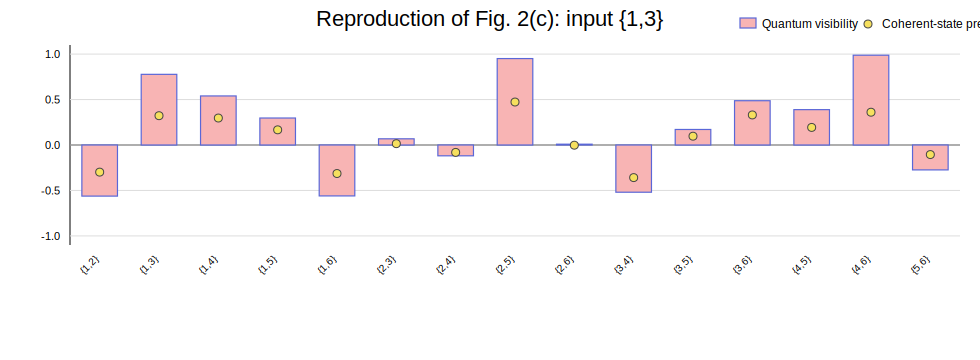

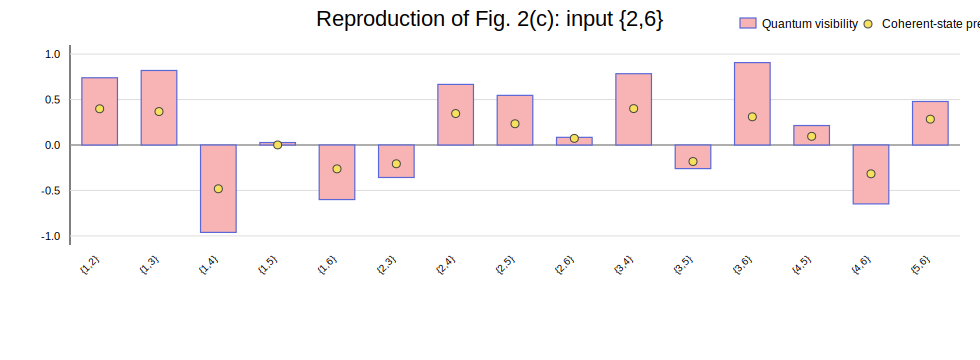

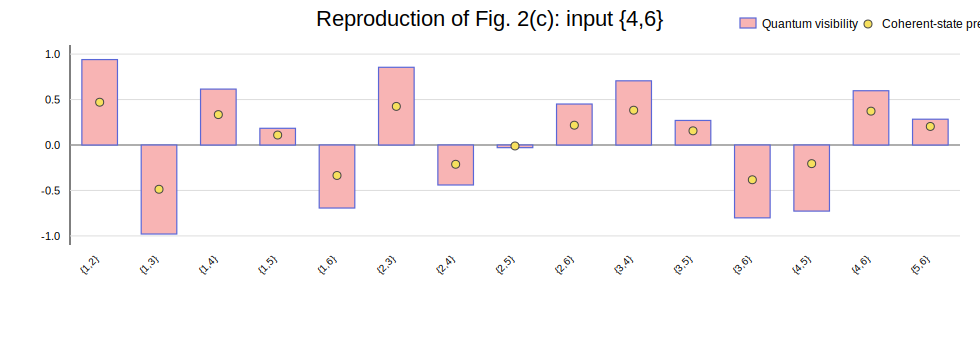

In [3]:
two_photon_inputs = [(1, 3), (2, 6), (4, 6)]

for input_modes in two_photon_inputs:
    S2 = occ_from_modes(input_modes)
    labels = []
    quantum_vis = []
    coherent_vis = []
    for out_modes, T2 in choose_noncolliding_outputs(2, m=6):
        Pq, _ = quantum_probability(U2, S2, T2)
        Pc = classical_probability(U2, S2, T2)
        labels.append("{" + ",".join(map(str, out_modes)) + "}")
        quantum_vis.append(visibility(Pc, Pq))
        coherent_vis.append(coherent_visibility(U2, input_modes, out_modes))

    title = f"Reproduction of Fig. 2(c): input {{{','.join(map(str, input_modes))}}}"
    show_svg(svg_visibility_panel(title, labels, quantum_vis, coherent_vis))

## Reproduction of Fig. 3: three-photon visibility structure

Figure 3 extends the same visibility comparison to the three-photon case. The paper shows three input configurations:

- `{1,3,5}`,
- `{1,4,6}`,
- `{1,5,6}`.

The notebook reproduces the theoretical visibility structure for those same inputs by evaluating all non-colliding three-photon outputs. As in the paper, the comparison is between:

- the permanent-based quantum visibility,
- and the coherent-state visibility prediction.

While presenting this section, the key point is that three-photon Boson Sampling is the central test of the paper, because it moves beyond the simpler two-photon interference regime.

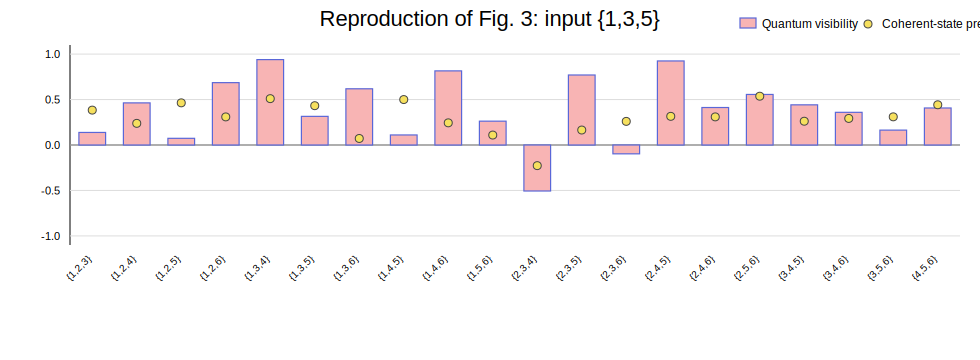

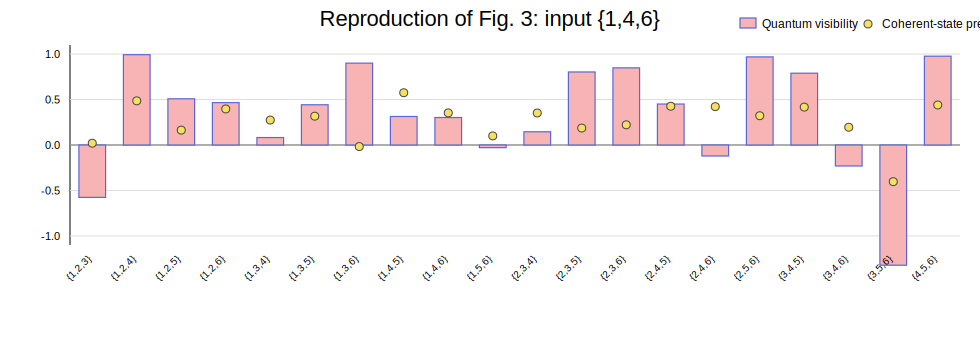

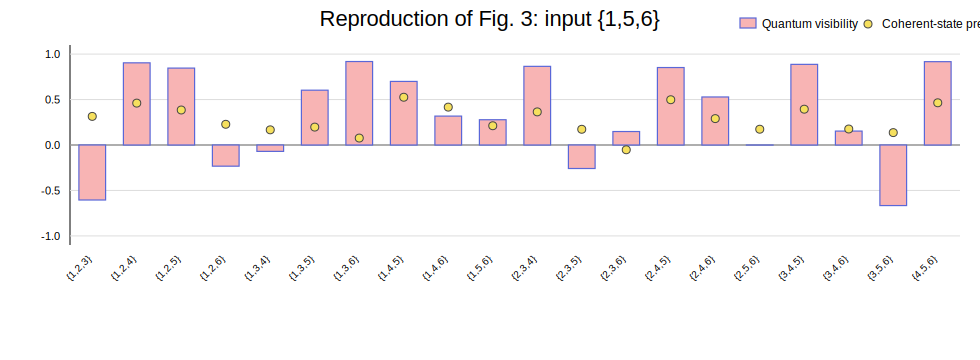

In [4]:
three_photon_inputs = [(1, 3, 5), (1, 4, 6), (1, 5, 6)]

for input_modes in three_photon_inputs:
    S3 = occ_from_modes(input_modes)
    labels = []
    quantum_vis = []
    coherent_vis = []
    for out_modes, T3 in choose_noncolliding_outputs(3, m=6):
        Pq, _ = quantum_probability(U3, S3, T3)
        Pc = classical_probability(U3, S3, T3)
        labels.append("{" + ",".join(map(str, out_modes)) + "}")
        quantum_vis.append(visibility(Pc, Pq))
        coherent_vis.append(coherent_visibility(U3, input_modes, out_modes, samples=3000))

    title = f"Reproduction of Fig. 3: input {{{','.join(map(str, input_modes))}}}"
    show_svg(svg_visibility_panel(title, labels, quantum_vis, coherent_vis))

## Reproduction of Fig. 4(b): colliding outputs

Figure 4 studies a more complicated output class in which two photons appear in the same output mode. In the paper this is done for input `{1,3,5}` and outputs that contain two photons in mode 5.

The notebook reproduces this by evaluating the colliding outputs:

- `{1,5,5}`,
- `{2,5,5}`,
- `{3,5,5}`,
- `{4,5,5}`,
- `{5,5,6}`.

This section is useful during the presentation because it shows that the same BosonSampling formalism still works even when collisions are present. The only difference is that the occupation-number description and the repeated-row/repeated-column construction now include repeated output modes.

Output  | Pq     | Pc     | Quantum visibility | Coherent visibility
--------+--------+--------+--------------------+--------------------
{1,5,5} | 0.0007 | 0.0121 | 0.943              | 0.127              
{2,5,5} | 0.0077 | 0.0094 | 0.182              | -0.170             
{3,5,5} | 0.0147 | 0.0139 | -0.059             | -0.651             
{4,5,5} | 0.0059 | 0.0069 | 0.149              | -0.364             
{5,5,6} | 0.0021 | 0.0090 | 0.762              | 0.046              


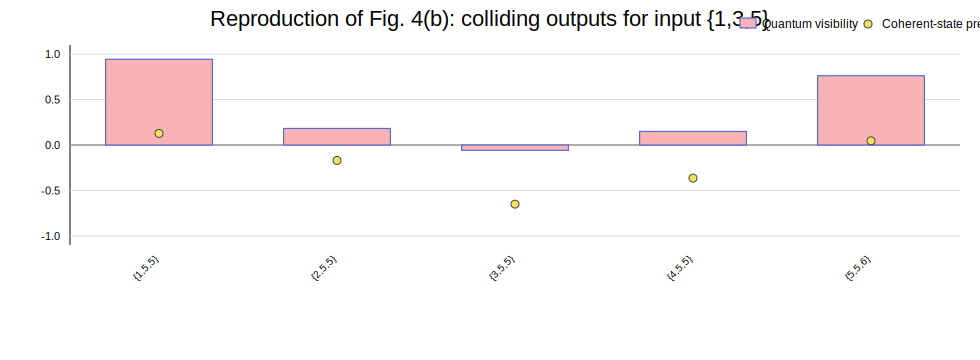

In [5]:
colliding_outputs = [
    (1, 5, 5),
    (2, 5, 5),
    (3, 5, 5),
    (4, 5, 5),
    (5, 5, 6),
]

input_modes_fig4 = (1, 3, 5)
S_fig4 = occ_from_modes(input_modes_fig4)

labels = []
quantum_vis = []
coherent_vis = []
rows = []

for out_modes in colliding_outputs:
    T4 = occ_from_modes(out_modes)
    Pq, _ = quantum_probability(U3, S_fig4, T4)
    Pc = classical_probability(U3, S_fig4, T4)
    Vq = visibility(Pc, Pq)
    Vcoh = coherent_visibility(U3, input_modes_fig4, out_modes, samples=3000)
    label = "{" + ",".join(map(str, out_modes)) + "}"
    labels.append(label)
    quantum_vis.append(Vq)
    coherent_vis.append(Vcoh)
    rows.append([label, f"{Pq:.4f}", f"{Pc:.4f}", f"{Vq:.3f}", f"{Vcoh:.3f}"])

display_table(rows, headers=["Output", "Pq", "Pc", "Quantum visibility", "Coherent visibility"])
show_svg(svg_visibility_panel("Reproduction of Fig. 4(b): colliding outputs for input {1,3,5}", labels, quantum_vis, coherent_vis))

## Reproduction of Fig. 5: imperfect Fock states and pump-power trend

Figure 5 in the paper illustrates how source imperfections affect the agreement between experiment and theory. As pump power increases, higher-order terms in the down-conversion source become more important, and the measured data move away from the ideal Fock-state prediction.

In this notebook, the trend is recreated using the values transcribed from the published figure. The plot shows the change in the $L_1$-norm distance between Bob's measurements and two theoretical references:

- Alice's ideal Fock-state prediction,
- Alice's coherent-state prediction.

This plot is especially useful in the video because it connects the abstract BosonSampling formulas to a practical limitation of the experiment: source brightness improves count rate, but too much brightness introduces higher-order photon-number contamination.

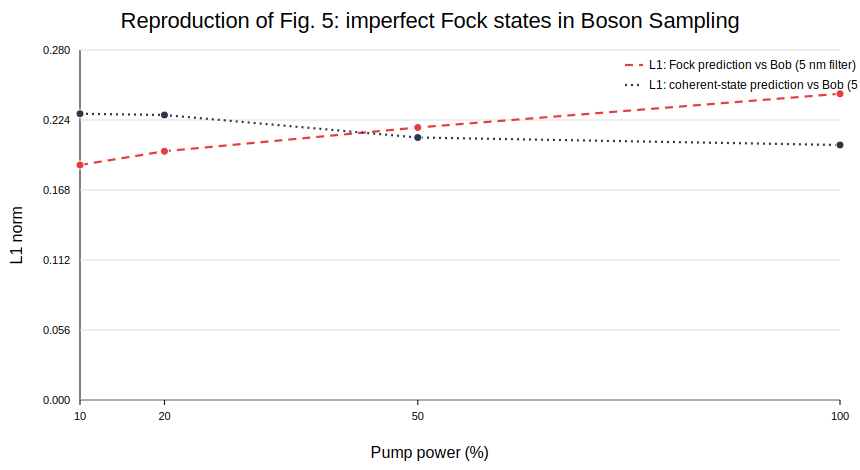

Pump power (%) | Fock vs Bob (approx. from figure) | Coherent vs Bob (approx. from figure)
---------------+-----------------------------------+--------------------------------------
10             | 0.188                             | 0.229                                
20             | 0.199                             | 0.228                                
50             | 0.218                             | 0.210                                
100            | 0.245                             | 0.204                                


In [6]:
pump_power = [10, 20, 50, 100]
l1_fock_5nm = [0.188, 0.199, 0.218, 0.245]
l1_coherent_5nm = [0.229, 0.228, 0.210, 0.204]

series = [
    {"name": "L1: Fock prediction vs Bob (5 nm filter)", "y": l1_fock_5nm, "color": "#e53e3e", "dash": "8,6"},
    {"name": "L1: coherent-state prediction vs Bob (5 nm filter)", "y": l1_coherent_5nm, "color": "#2d3748", "dash": "2,4"},
]

show_svg(
    svg_line_chart(
        "Reproduction of Fig. 5: imperfect Fock states in Boson Sampling",
        pump_power,
        series,
        x_label="Pump power (%)",
        y_label="L1 norm",
        y_min=0.0,
        y_max=0.28,
    )
)

display_table(
    [
        [10, "0.188", "0.229"],
        [20, "0.199", "0.228"],
        [50, "0.218", "0.210"],
        [100, "0.245", "0.204"],
    ],
    headers=["Pump power (%)", "Fock vs Bob (approx. from figure)", "Coherent vs Bob (approx. from figure)"],
)

## Closing note for presentation

This notebook is meant to be shown directly during the video. A good presentation flow is:

1. begin with the worked permanent example,
2. move to the two-photon visibility structure,
3. then show the three-photon case as the main BosonSampling result,
4. then discuss colliding outputs,
5. and finally close with the source-imperfection trend in Fig. 5.

This order mirrors the logic of the paper and helps connect the mathematics, the plots, and the physical interpretation in a coherent way.